# Curriculum Learning for Unitary Compilation — Report

Thesis-ready figures and summary for the `unitary-curriculum-learning` experiment.

**Experiment**: Does pre-training on Clifford-only circuits (stage 1, quditkit) before fine-tuning on the full gate set (stage 2, qiskit) improve unitary compilation accuracy over training from scratch?

**Evaluation**: 128 target unitaries × 128 generated circuits each, guidance_scale=7.5, DDIM 20 steps, `max_gates=12`.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("/home/a-ldungl/projects/qcircuit-generation")
from notebooks.shared.bootstrap import setup_notebook_paths
PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import make_artifact_dir, save_figure, save_dataframe

ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, "curriculum-learning", "curriculum_learning_report")
REPORT_DIR   = PROJECT_ROOT / "reports" / "curriculum-learning"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi":          150,
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.titlepad":       10,
    "axes.labelsize":      11,
    "axes.labelpad":       6,
    "axes.grid":           True,
    "grid.linestyle":      "--",
    "grid.linewidth":      0.6,
    "grid.alpha":          0.5,
    "grid.color":          "#AAAAAA",
    "axes.axisbelow":      True,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
    "legend.fontsize":     10,
    "legend.framealpha":   0.92,
    "legend.edgecolor":    "#CCCCCC",
    "lines.linewidth":     2.0,
    "lines.markersize":    6,
    "font.family":         "sans-serif",
})

# Semantic colour assignments
COLORS = {
    "remote":            "#2176AE",
    "baseline":          "#E05C2A",
    "stage2_scratch":    "#3BAA6E",
    "curriculum_stage2": "#8B5CF6",
}
DISPLAY_NAMES = {
    "remote":            "Remote (paper weights)",
    "baseline":          "Baseline (reproduced)",
    "stage2_scratch":    "Stage-2 from scratch",
    "curriculum_stage2": "Curriculum stage-2",
}

In [2]:
# --- Load evaluation results ---
EVAL_PKL = PROJECT_ROOT / "artifacts/evaluations/curriculum-learning/curriculum_final_eval/results.pkl"

with open(EVAL_PKL, "rb") as f:
    results = pickle.load(f)

summary_df = pd.DataFrame([results[k]["summary"] for k in results]).set_index("model")
print(summary_df[["exact_found_rate", "mean_distinct_correct", "mean_exact_count", "mean_valid_decode_rate"]].round(4))

                   exact_found_rate  mean_distinct_correct  mean_exact_count  \
model                                                                          
remote                       0.9844                30.8672           86.2812   
baseline                     0.9688                32.9141           83.8281   
stage2_scratch               0.9375                13.6562           59.1641   
curriculum_stage2            0.9219                24.3203           76.7734   

                   mean_valid_decode_rate  
model                                      
remote                             0.9916  
baseline                           0.9965  
stage2_scratch                     0.9976  
curriculum_stage2                  0.9918  


In [3]:
# --- Load per-unitary data for box plots ---
per_unitary = {k: results[k]["per_unitary"] for k in results}

# --- Load validation loss curves (one value per epoch) ---
def load_valid_losses(path):
    """Load fit_valid_losses.txt — format: 'step loss' per line."""
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                rows.append(float(parts[1]))
            elif len(parts) == 1:
                rows.append(float(parts[0]))
    return np.array(rows)

MODEL_DIRS = {
    "baseline":          PROJECT_ROOT / "artifacts/models/unitary-baseline-reproduction/paper_unitary",
    "stage2_scratch":    PROJECT_ROOT / "artifacts/models/unitary-curriculum-learning/stage2_scratch",
    "curriculum_stage1": PROJECT_ROOT / "artifacts/models/unitary-curriculum-learning/unitary_curriculum_stage1",
    "curriculum_stage2": PROJECT_ROOT / "artifacts/models/unitary-curriculum-learning/stage2",
}

valid_losses = {}
for label, model_dir in MODEL_DIRS.items():
    vl_path = model_dir / "fit_valid_losses.txt"
    if vl_path.exists():
        valid_losses[label] = load_valid_losses(vl_path)
        print(f"{label}: {len(valid_losses[label])} epochs, final val loss = {valid_losses[label][-1]:.4f}")

baseline: 150 epochs, final val loss = 0.0126
stage2_scratch: 150 epochs, final val loss = 0.0155
curriculum_stage1: 150 epochs, final val loss = 0.0121
curriculum_stage2: 150 epochs, final val loss = 0.0147


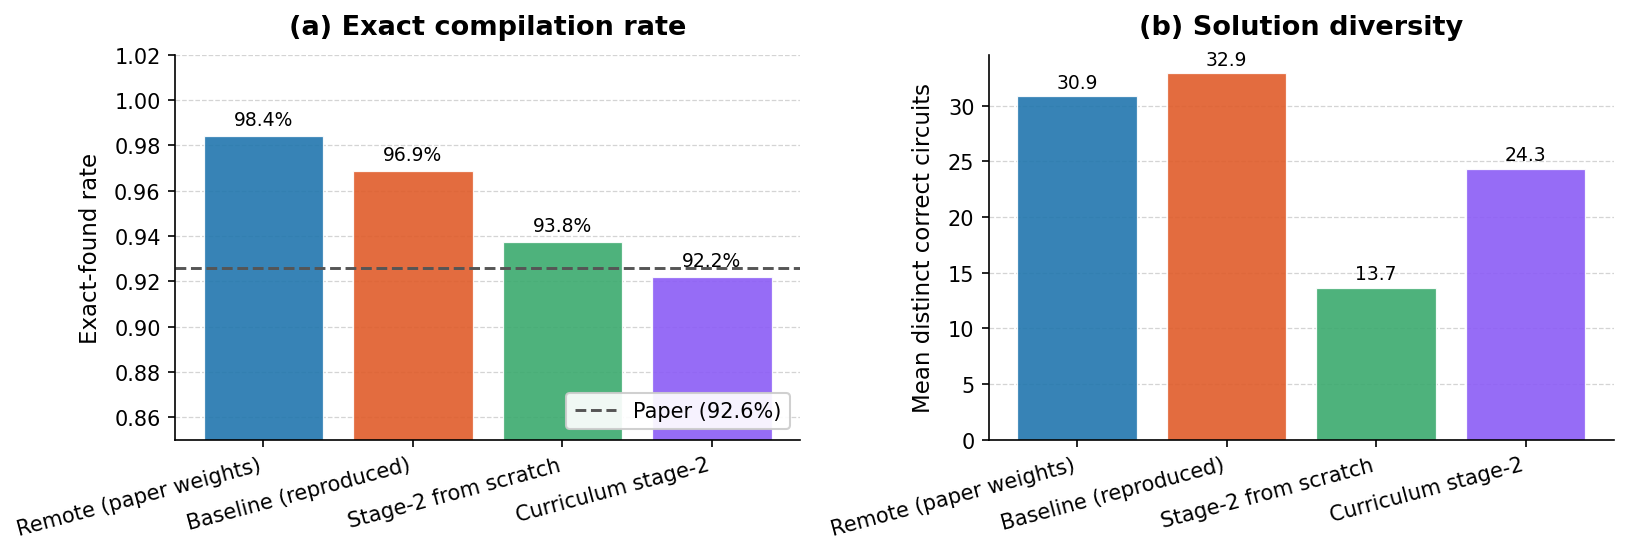

In [4]:
# ============================================================
# Figure 1: Accuracy & diversity comparison (grouped bar)
# ============================================================
MODELS_EVAL = ["remote", "baseline", "stage2_scratch", "curriculum_stage2"]
x = np.arange(len(MODELS_EVAL))
labels = [DISPLAY_NAMES[m] for m in MODELS_EVAL]
colors = [COLORS[m] for m in MODELS_EVAL]

exact_rates    = [summary_df.loc[m, "exact_found_rate"] for m in MODELS_EVAL]
distinct_means = [summary_df.loc[m, "mean_distinct_correct"] for m in MODELS_EVAL]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# (a) Exact-found rate
ax = axes[0]
bars = ax.bar(x, exact_rates, color=colors, alpha=0.90, edgecolor="white", linewidth=0.6)
ax.axhline(0.926, color="#555555", linestyle="--", linewidth=1.4, label="Paper (92.6%)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Exact-found rate")
ax.set_title("(a) Exact compilation rate")
ax.set_ylim(0.85, 1.02)
ax.yaxis.grid(True)
ax.xaxis.grid(False)
ax.legend(loc="lower right")
# Annotate bars
for bar, val in zip(bars, exact_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)

# (b) Mean distinct correct circuits
ax = axes[1]
bars = ax.bar(x, distinct_means, color=colors, alpha=0.90, edgecolor="white", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Mean distinct correct circuits")
ax.set_title("(b) Solution diversity")
ax.yaxis.grid(True)
ax.xaxis.grid(False)
for bar, val in zip(bars, distinct_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "accuracy_diversity_comparison.png")
save_figure(fig, REPORT_DIR / "accuracy_diversity_comparison.png")
plt.show()

/tmp/ipykernel_710649/2752934707.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


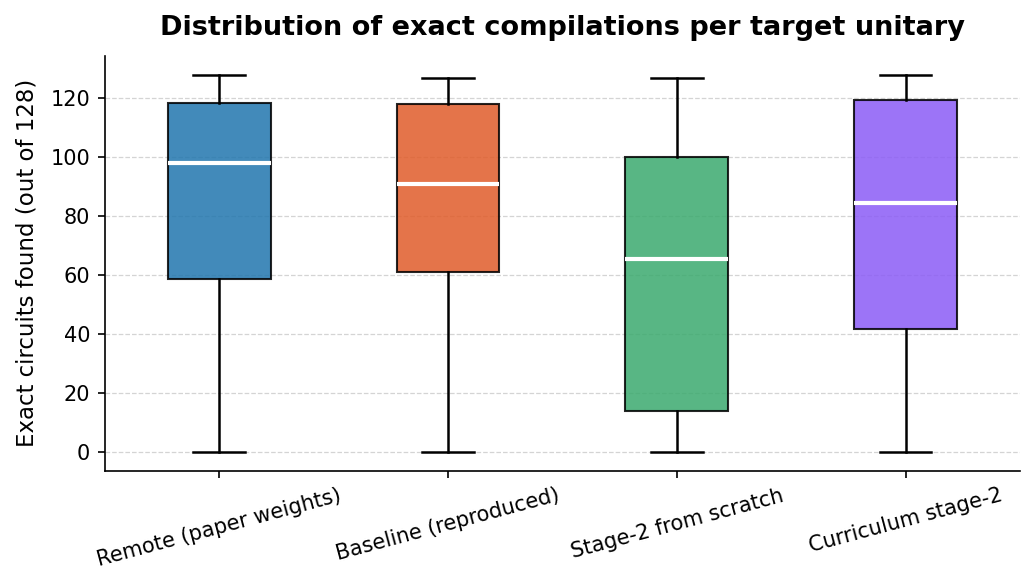

In [5]:
# ============================================================
# Figure 2: Per-unitary exact count — box plots
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4))

box_data  = [per_unitary[m]["exact_count"].to_numpy(dtype=float) for m in MODELS_EVAL]
bp = ax.boxplot(
    box_data,
    labels=labels,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_ylabel("Exact circuits found (out of 128)")
ax.set_title("Distribution of exact compilations per target unitary")
ax.tick_params(axis="x", rotation=15)
ax.yaxis.grid(True)
ax.xaxis.grid(False)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "exact_count_boxplot.png")
save_figure(fig, REPORT_DIR / "exact_count_boxplot.png")
plt.show()

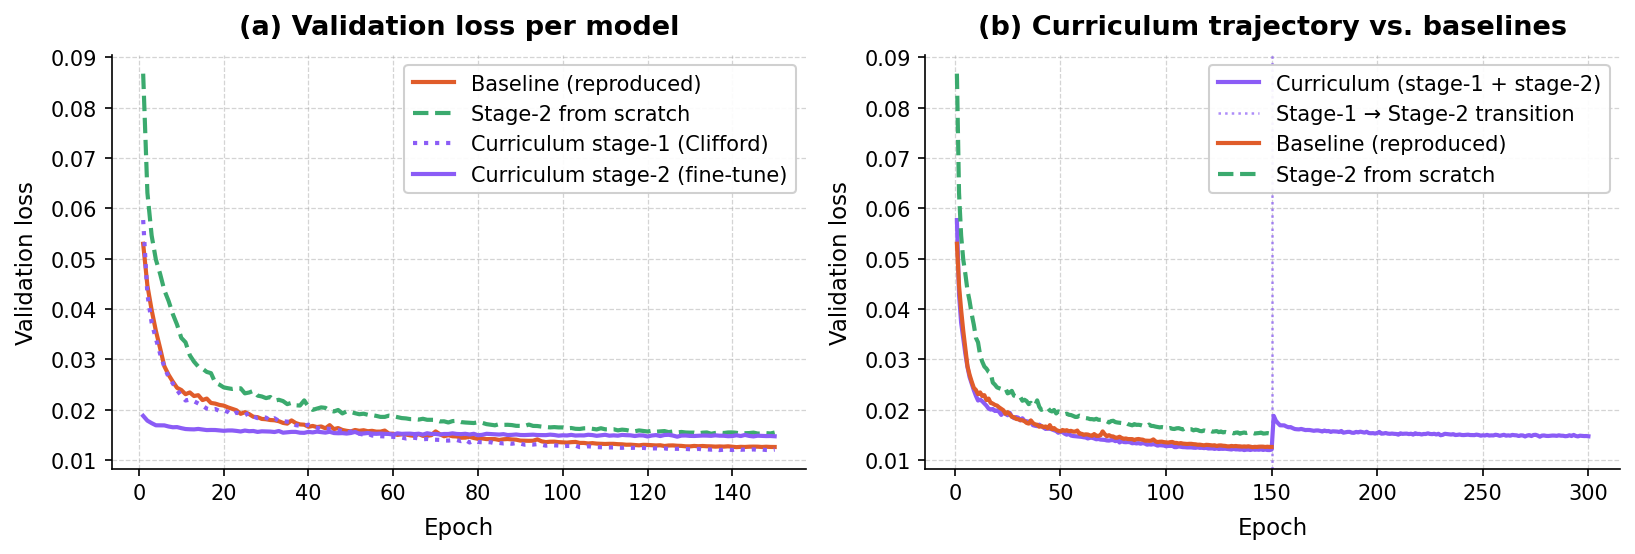

In [6]:
# ============================================================
# Figure 3: Validation loss curves
# ============================================================
# Stage1 and stage2 are sequential for the curriculum approach —
# concatenate them for a continuous curriculum training curve.

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# (a) All individual model curves
ax = axes[0]
VL_STYLE = {
    "baseline":          {"color": COLORS["baseline"],          "linestyle": "-",  "label": DISPLAY_NAMES["baseline"]},
    "stage2_scratch":    {"color": COLORS["stage2_scratch"],    "linestyle": "--", "label": DISPLAY_NAMES["stage2_scratch"]},
    "curriculum_stage2": {"color": COLORS["curriculum_stage2"], "linestyle": "-",  "label": "Curriculum stage-2 (fine-tune)"},
    "curriculum_stage1": {"color": COLORS["curriculum_stage2"], "linestyle": ":",  "label": "Curriculum stage-1 (Clifford)"},
}
for label, vl in valid_losses.items():
    style = VL_STYLE.get(label, {})
    epochs = np.arange(1, len(vl) + 1)
    ax.plot(epochs, vl, **style, marker="o", markersize=0)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.set_title("(a) Validation loss per model")
ax.legend()

# (b) Curriculum concatenated vs. baseline and scratch
ax = axes[1]
if "curriculum_stage1" in valid_losses and "curriculum_stage2" in valid_losses:
    vl_s1 = valid_losses["curriculum_stage1"]
    vl_s2 = valid_losses["curriculum_stage2"]
    vl_curriculum_full = np.concatenate([vl_s1, vl_s2])
    epochs_full = np.arange(1, len(vl_curriculum_full) + 1)
    ax.plot(epochs_full, vl_curriculum_full, color=COLORS["curriculum_stage2"],
            linestyle="-", label="Curriculum (stage-1 + stage-2)", marker="o", markersize=0)
    ax.axvline(len(vl_s1), color=COLORS["curriculum_stage2"], linestyle=":",
               linewidth=1.2, alpha=0.7, label="Stage-1 → Stage-2 transition")

if "baseline" in valid_losses:
    vl_b = valid_losses["baseline"]
    ax.plot(np.arange(1, len(vl_b) + 1), vl_b, color=COLORS["baseline"],
            linestyle="-", label=DISPLAY_NAMES["baseline"], marker="o", markersize=0)

if "stage2_scratch" in valid_losses:
    vl_s = valid_losses["stage2_scratch"]
    ax.plot(np.arange(1, len(vl_s) + 1), vl_s, color=COLORS["stage2_scratch"],
            linestyle="--", label=DISPLAY_NAMES["stage2_scratch"], marker="o", markersize=0)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.set_title("(b) Curriculum trajectory vs. baselines")
ax.legend()

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "training_loss_curves.png")
save_figure(fig, REPORT_DIR / "training_loss_curves.png")
plt.show()

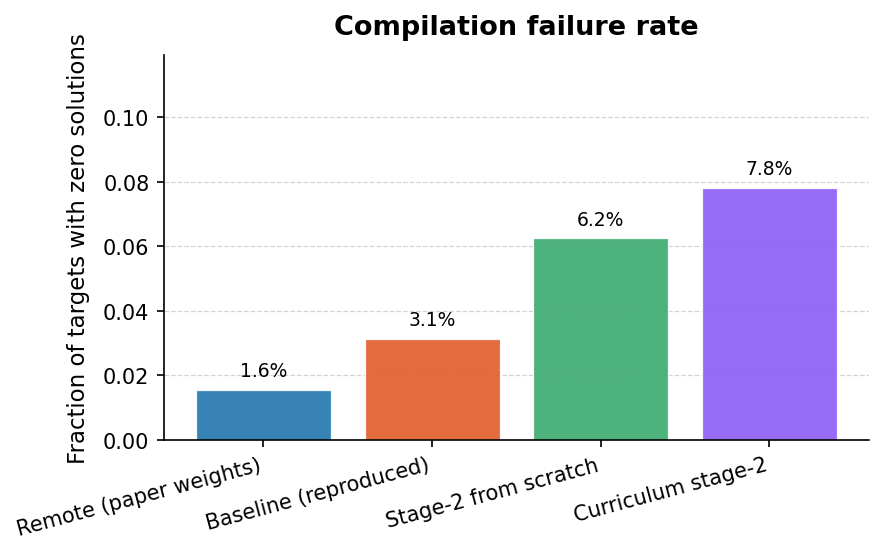

In [7]:
# ============================================================
# Figure 4: Exact-found rate vs. zero-shot on hard targets
# Split per unitary: proportion of unitaries where exact_count == 0
# ============================================================
fail_rates = {}
for m in MODELS_EVAL:
    df = per_unitary[m]
    fail_rates[m] = (df["exact_found"] == False).mean()

fig, ax = plt.subplots(figsize=(6, 3.8))
fail_vals = [fail_rates[m] for m in MODELS_EVAL]
bars = ax.bar(x, fail_vals, color=colors, alpha=0.90, edgecolor="white", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Fraction of targets with zero solutions")
ax.set_title("Compilation failure rate")
ax.set_ylim(0, max(fail_vals) * 1.4 + 0.01)
ax.yaxis.grid(True)
ax.xaxis.grid(False)
for bar, val in zip(bars, fail_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "failure_rate.png")
save_figure(fig, REPORT_DIR / "failure_rate.png")
plt.show()

In [8]:
# ============================================================
# Summary CSV
# ============================================================
cols = ["exact_found_rate", "mean_exact_count", "median_exact_count",
        "mean_distinct_correct", "median_distinct_correct", "mean_valid_decode_rate"]
out_df = summary_df[cols].copy()
out_df.index.name = "model"

save_dataframe(out_df.reset_index(), ARTIFACT_DIR / "summary.csv", index=False)
save_dataframe(out_df.reset_index(), REPORT_DIR / "summary.csv", index=False)

print(out_df.round(4))

                   exact_found_rate  mean_exact_count  median_exact_count  \
model                                                                       
remote                       0.9844           86.2812                98.0   
baseline                     0.9688           83.8281                91.0   
stage2_scratch               0.9375           59.1641                65.5   
curriculum_stage2            0.9219           76.7734                84.5   

                   mean_distinct_correct  median_distinct_correct  \
model                                                               
remote                           30.8672                     25.0   
baseline                         32.9141                     27.5   
stage2_scratch                   13.6562                     11.0   
curriculum_stage2                24.3203                     16.5   

                   mean_valid_decode_rate  
model                                      
remote                            

In [9]:
print(f"Report figures saved to: {REPORT_DIR}")
for f in sorted(REPORT_DIR.iterdir()):
    print(f" - {f.name}")

Report figures saved to: /home/a-ldungl/projects/qcircuit-generation/reports/curriculum-learning
 - accuracy_diversity_comparison.png
 - exact_count_boxplot.png
 - failure_rate.png
 - notes.md
 - summary.csv
 - training_loss_curves.png
